In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
from tqdm.notebook import tqdm

rng = np.random.default_rng()

In [2]:
data = pd.read_csv('https://stepik.org/media/attachments/lesson/1253070/train.csv', index_col=0)
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.8140,6.0,4.169837,1.019022,1541.0,2.093750,32.92,-117.14,1.325
1,2.3365,34.0,4.466063,1.122172,902.0,4.081448,33.95,-118.27,0.980
2,4.1250,29.0,5.264264,1.027027,1318.0,3.957958,34.23,-118.54,2.414
3,4.0625,52.0,3.645161,0.930108,791.0,4.252688,34.11,-118.20,1.713
4,2.8357,17.0,5.308256,1.059254,2899.0,1.930093,38.37,-121.94,1.201


In [3]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.811267,28.691000,5.411049,1.101693,1437.759000,2.967903,35.588200,-119.521690,2.043786
std,1.807486,12.593602,3.404713,0.796931,1178.688691,1.574853,2.119325,1.990368,1.135230
min,0.677500,2.000000,0.846154,0.526316,8.000000,1.318600,32.550000,-124.180000,0.149990
25%,2.541400,18.000000,4.401747,1.004202,775.750000,2.436703,33.930000,-121.640000,1.196000
50%,3.528150,29.000000,5.218337,1.047099,1165.000000,2.822778,34.230000,-118.470000,1.781000
75%,4.654925,37.000000,6.002827,1.095123,1743.750000,3.291604,37.700000,-118.000000,2.606250
max,15.000100,52.000000,132.533333,34.066667,16122.000000,63.750000,41.630000,-114.660000,5.000010


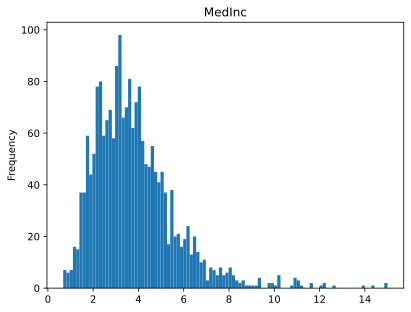

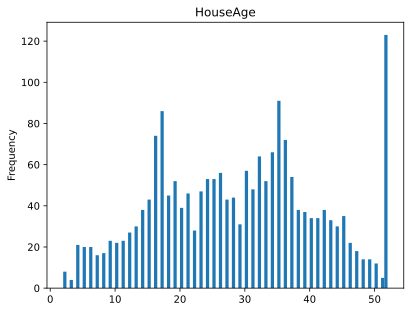

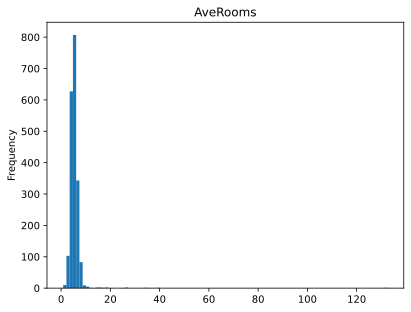

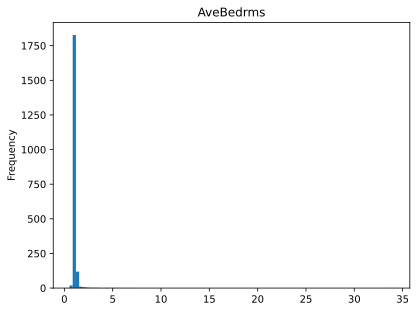

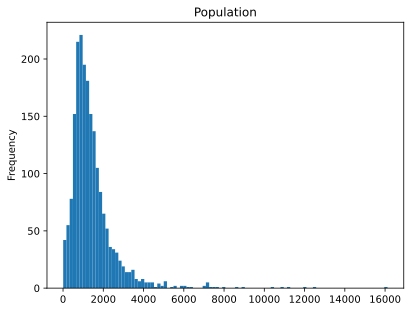

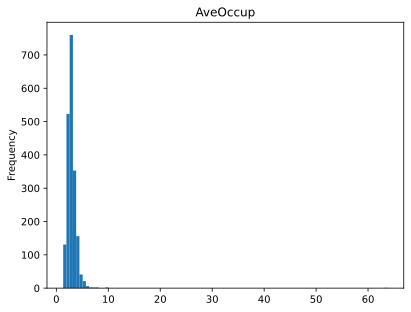

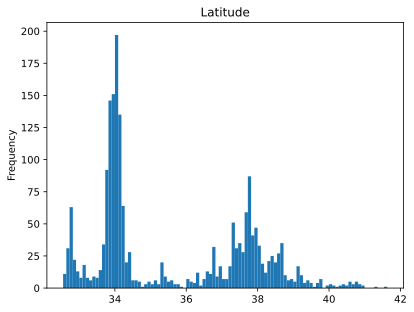

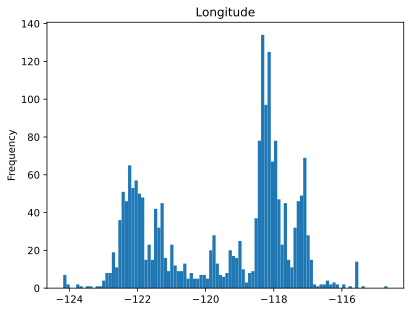

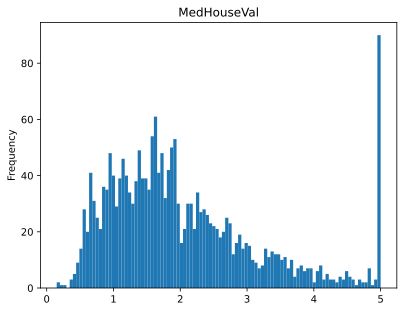

In [4]:
for col in data.columns:
    data[col].plot.hist(bins=100)
    plt.title(col)
    plt.show()

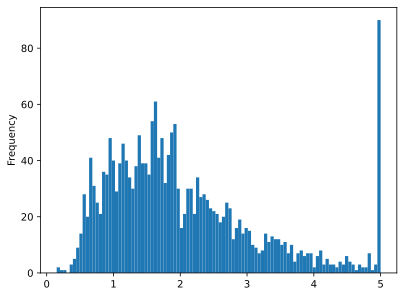

In [5]:
data.MedHouseVal.plot.hist(bins=100)
plt.show()

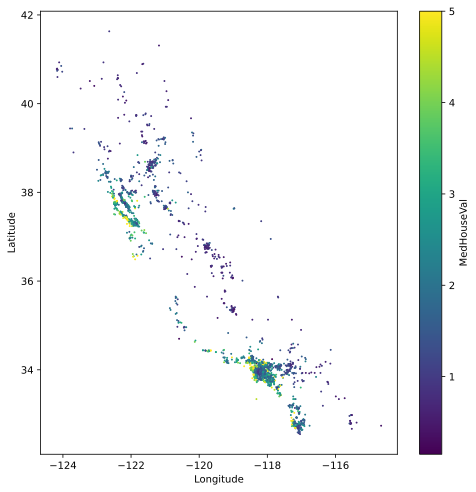

In [6]:
data.plot.scatter(x='Longitude', y='Latitude', c='MedHouseVal', figsize=(8, 8), s=1)
plt.show()

In [7]:
from sklearn.preprocessing import RobustScaler, PolynomialFeatures, StandardScaler, PowerTransformer, OneHotEncoder, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

In [8]:
from sklearn.base import TransformerMixin, BaseEstimator

class Clamp(TransformerMixin, BaseEstimator):
    def __init__(self, *, upper_bound=None):
        self.upper_bound = upper_bound if upper_bound else np.inf

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        ans = np.minimum(X, self.upper_bound)
        if y is not None:
            return ans, y
        return ans

clamp_step = ColumnTransformer([
    ('clamp_rooms', Clamp(upper_bound=10), ['AveRooms']),
    ('clamp_bedrms', Clamp(upper_bound=3), ['AveBedrms']),
    ('clamp_occup', Clamp(upper_bound=6), ['AveOccup']),
    ('clamp_population', Clamp(upper_bound=5000), ['Population']),
], remainder='passthrough')

numeric_features = ['MedInc',	'HouseAge',	'AveRooms',	'AveBedrms',	'Population',	'AveOccup',	'Latitude',	'Longitude']
numeric_transformer = Pipeline([
    ('clamp', clamp_step),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

class GeoClusterEncoder(BaseEstimator, TransformerMixin):
    """Кластеризует координаты и возвращает one-hot кодировку кластеров."""
    def __init__(self, n_clusters=20, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    def fit(self, X, y=None):
        # X - DataFrame или array с колонками широты и долготы
        coords = X.values if hasattr(X, 'values') else X
        self.kmeans.fit(coords)
        clusters = self.kmeans.labels_.reshape(-1, 1)
        self.encoder.fit(clusters)
        return self

    def transform(self, X):
        coords = X.values if hasattr(X, 'values') else X
        clusters = self.kmeans.predict(coords).reshape(-1, 1)
        return self.encoder.transform(clusters)

geo_transformer = Pipeline([
    ('geo_cluster', GeoClusterEncoder(n_clusters=100))  # возвращает one-hot
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('geo', geo_transformer, ['Latitude', 'Longitude'])
])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression()),
])

model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,        # log(1 + y)
    inverse_func=np.expm1 # exp(y) - 1
)

In [19]:
X = data.drop('MedHouseVal', axis=1)
y = data.MedHouseVal
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1800, 8), (200, 8), (1800,), (200,))

In [20]:
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('Train RMSE: ', rmse(y_train, y_pred_train))
print('Test RMSE: ', rmse(y_test, y_pred_test))

Train RMSE:  0.5037433818330919
Test RMSE:  0.48033672114149706


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


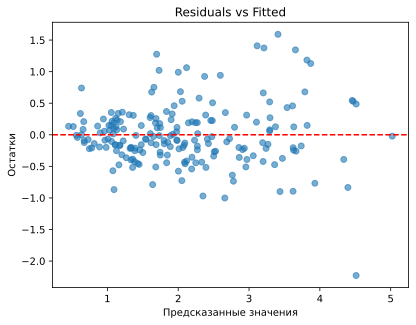

In [21]:
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Residuals vs Fitted')
plt.show()

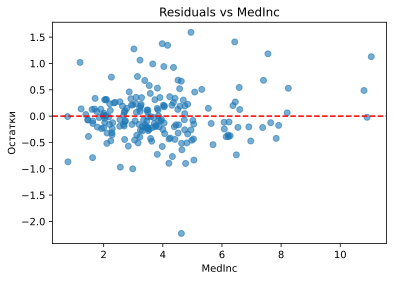

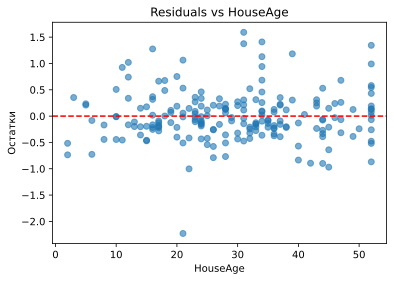

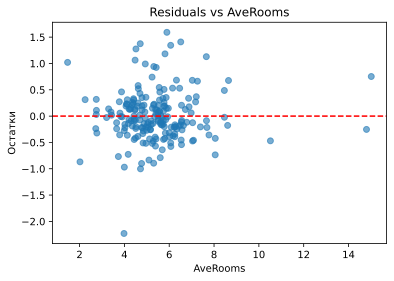

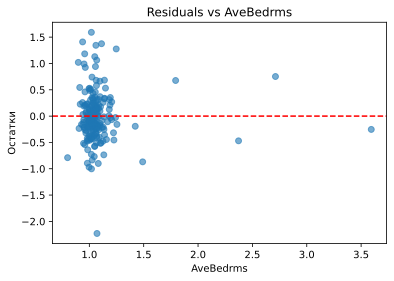

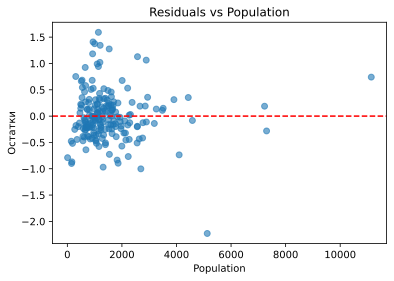

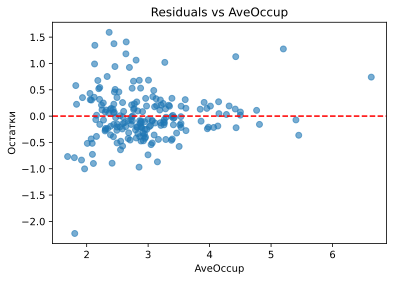

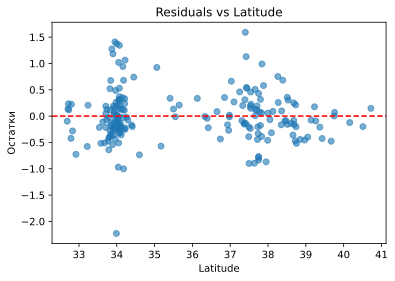

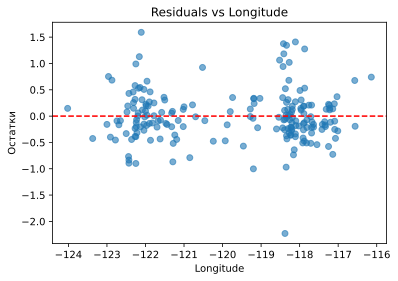

In [22]:
for feature in X_test.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(X_test[feature], residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(feature)
    plt.ylabel('Остатки')
    plt.title(f'Residuals vs {feature}')
    plt.show()

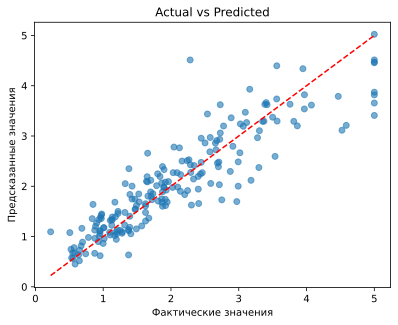

In [23]:
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Actual vs Predicted')
plt.show()

In [24]:
test = pd.read_csv('https://stepik.org/media/attachments/lesson/1253070/test.csv', index_col=0)

pred = model.predict(test)
with open('solution.csv', 'w') as file:
    file.write('\n'.join([f'{x}' for x in pred]))

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
